In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("cardio_train.csv", sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
# DATA PREPARATION

print("1. CHECKING DATA TYPES")
print("-" * 30)

# Display current data types
print("DataFrame Info:")
print(df.info())

# Identify numerical columns only
numerical_columns = df.select_dtypes(include=['number']).columns
print(f"\n Numerical columns selected: {len(numerical_columns)}")
print(f"Features: {list(numerical_columns)}")

# Create numerical-only dataframe
numerical_df = df[numerical_columns]
print(f"Working dataset: {numerical_df.shape[0]} rows, {numerical_df.shape[1]} columns")

1. CHECKING DATA TYPES
------------------------------
DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None

 Numerical columns selected: 13
Features: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke'

In [6]:
# CORRELATION CALCULATION

print("\n2. CALCULATING CORRELATION MATRIX")
print("-" * 30)

# Calculate correlation matrix
correlation_matrix = numerical_df.corr()
print(f"Correlation matrix shape: {correlation_matrix.shape}")

# Display correlation matrix values
print("\nCorrelation Matrix Values:")
print(correlation_matrix.round(3))


2. CALCULATING CORRELATION MATRIX
------------------------------
Correlation matrix shape: (13, 13)

Correlation Matrix Values:
                id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  \
id           1.000  0.003   0.004  -0.003  -0.002  0.003 -0.003        0.006   
age          0.003  1.000  -0.023  -0.082   0.054  0.021  0.018        0.154   
gender       0.004 -0.023   1.000   0.499   0.155  0.006  0.015       -0.036   
height      -0.003 -0.082   0.499   1.000   0.291  0.005  0.006       -0.050   
weight      -0.002  0.054   0.155   0.291   1.000  0.031  0.044        0.142   
ap_hi        0.003  0.021   0.006   0.005   0.031  1.000  0.016        0.024   
ap_lo       -0.003  0.018   0.015   0.006   0.044  0.016  1.000        0.024   
cholesterol  0.006  0.154  -0.036  -0.050   0.142  0.024  0.024        1.000   
gluc         0.002  0.099  -0.020  -0.019   0.107  0.012  0.011        0.452   
smoke       -0.004 -0.048   0.338   0.188   0.068 -0.001  0.005        


3. CREATING CORRELATION HEATMAP
------------------------------


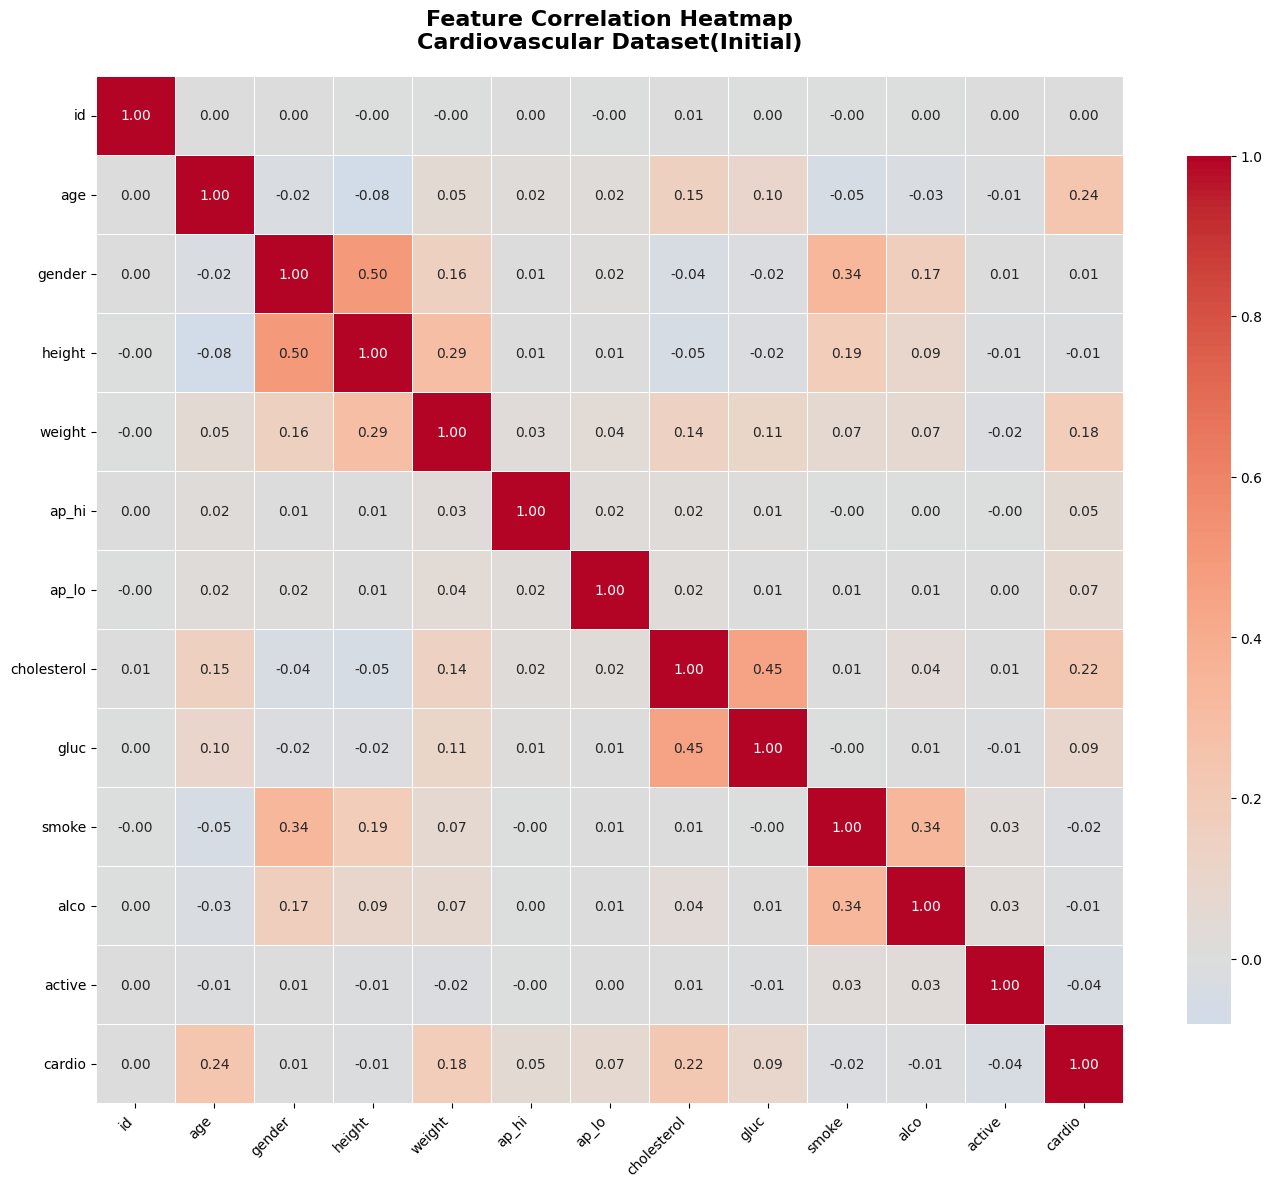

In [8]:
# HEATMAP VISUALIZATION

print("\n3. CREATING CORRELATION HEATMAP")
print("-" * 30)

# Set up the figure
plt.figure(figsize=(14, 12))

# Create the heatmap
heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,           # Show correlation values
    cmap='coolwarm',      # Color scheme (blue-white-red)
    center=0,             # Center colormap at 0
    fmt='.2f',            # Format numbers to 2 decimal places
    linewidths=0.5,       # Add lines between cells
    square=True,          # Make cells square
    cbar_kws={"shrink": 0.8}  # Size of color bar
)

# Customize titles and labels
plt.title('Feature Correlation Heatmap\nCardiovascular Dataset(Initial)',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.yticks(rotation=0)               # Keep y-axis labels horizontal

plt.tight_layout()
plt.show()